In [1]:
from transformers import AutoTokenizer, AutoModel
import torch
import transformers

print("Transformers version :", transformers.__version__)

Transformers version : 4.41.2


In [2]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True
)

print("Model loaded successfully")

Model loaded successfully


In [4]:
texts = [
    "Transformers are powerful models",
    "Deep learning changes NLP",
    "Bonjour tout le monde",
    "مرحبا بالعالم"
]

inputs = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

print(inputs)

{'input_ids': tensor([[  101, 19081,  2024,  3928,  4275,   102,     0,     0,     0,     0,
             0,     0,     0,     0],
        [  101,  2784,  4083,  3431, 17953,  2361,   102,     0,     0,     0,
             0,     0,     0,     0],
        [  101, 14753, 23099,  2099,  2000,  4904,  3393, 23117,   102,     0,
             0,     0,     0,     0],
        [  101,  1295, 17149, 29820, 29816, 25573,  1271, 25573, 23673, 29830,
         25573, 23673, 22192,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [5]:
for text in texts:
    tokens = tokenizer.tokenize(text)

    print("\nPhrase :", text)
    print("Tokens :", tokens)


Phrase : Transformers are powerful models
Tokens : ['transformers', 'are', 'powerful', 'models']

Phrase : Deep learning changes NLP
Tokens : ['deep', 'learning', 'changes', 'nl', '##p']

Phrase : Bonjour tout le monde
Tokens : ['bon', '##jou', '##r', 'to', '##ut', 'le', 'monde']

Phrase : مرحبا بالعالم
Tokens : ['م', '##ر', '##ح', '##ب', '##ا', 'ب', '##ا', '##ل', '##ع', '##ا', '##ل', '##م']


In [6]:
outputs = model(**inputs)

print("Shape outputs :")
print(outputs.last_hidden_state.shape)

Shape outputs :
torch.Size([4, 14, 768])


In [7]:
cls_embedding = outputs.last_hidden_state[:, 0, :]

print("CLS embedding shape :")
print(cls_embedding.shape)

CLS embedding shape :
torch.Size([4, 768])


In [8]:
attention_outputs = model(
    **inputs,
    output_attentions=True
)

attentions = attention_outputs.attentions

print("Nombre de couches :", len(attentions))

Nombre de couches : 6


In [9]:
layer_attention = attentions[0]

print(layer_attention.shape)

torch.Size([4, 12, 14, 14])


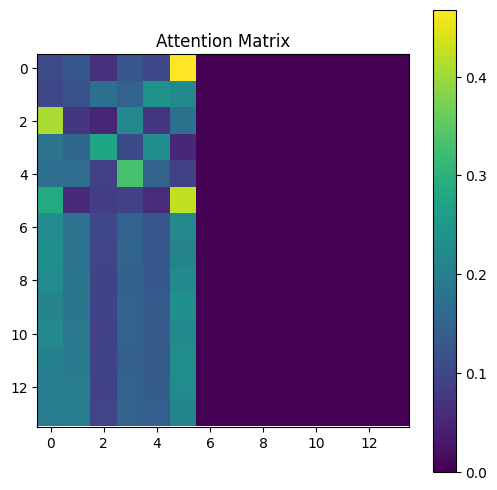

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(
    layer_attention[0][0].detach().numpy()
)

plt.title("Attention Matrix")
plt.colorbar()

plt.show()